# Phase 2 — Late-Order Negative Review Classification

This notebook tests a simple hypothesis: **among orders that were delivered late, can Logistic Regression predict which customers are likely to give a negative review (1–2 stars)?**

“The customer has already received their order late. Will they now give us a bad review?”

The workflow is intentionally simple and aligned to the project scope: prepare the data, split into training and test sets, fit one Logistic Regression model, evaluate it, interpret it, and save it for Phase 3.


## 1. Define the problem

**Target**
* `1`: review score 1–2 (negative review)
* `0`: review score 3–5

**Modelling population:** orders that were delivered, have an actual customer-delivery date, were delivered late, and subsequently received a review. One row represents one eligible late order.

**Prediction point:** **immediately after a late delivery is completed, before the customer submits their review.**

Phase 1 defines `days_early` so negative values mean late. For example, `-10` means 10 days late. Because delivery has already occurred at the prediction point, actual-delivery features such as `delivery_days` and `days_early` are available and are not target leakage. They would need to be excluded if the prediction point moved to before delivery.

Review IDs, review text and review timestamps are excluded because they are only known after the outcome. Phase 2 reuses the cleaned Phase 1 analytical tables.

Key Question **“The customer has already received their order late. Will they now give us a bad review?”**


### Load the Phase 1 data

The notebook uses `data/processed/order_level.csv` and `data/processed/item_level.csv`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification_data import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    NUMERIC_FEATURES,
    TARGET_COLUMN,
    build_classification_dataset,
    split_features_target,
)
from src.classification_evaluation import classification_metrics
from src.classification_model import (
    build_logistic_pipeline,
    predict_from_artifact,
    save_inference_artifact,
)

RANDOM_SEED = 42
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

order_level = pd.read_csv(PROCESSED_DIR / "order_level.csv")
item_level = pd.read_csv(PROCESSED_DIR / "item_level.csv")

print(f"order_level: {order_level.shape}")
print(f"item_level: {item_level.shape}")


order_level: (99441, 36)
item_level: (112650, 20)


### Build the modelling dataset

`build_classification_dataset(...)` validates the source schemas and keys, applies the four eligibility conditions below, aggregates item data to order level, constructs the target, and returns the feature contract in a fixed order. The detailed validation and feature construction are implemented in `src/classification_data.py`; the notebook surfaces the key modelling decisions and outputs for readability.

The cumulative population audit reproduces only the documented eligibility masks so the reader can see how many orders remain after each stage; it does not replace or alter the reusable implementation. The target created by the function is `1` for review scores 1–2 and `0` for scores 3–5.


In [2]:
delivered_at = pd.to_datetime(
    order_level["order_delivered_customer_date"], errors="coerce"
)
population_masks = [
    ("All source orders", pd.Series(True, index=order_level.index)),
    ("Delivered status", order_level["order_status"].eq("delivered")),
    ("Actual customer-delivery date present", delivered_at.notna()),
    ("Delivered late", order_level["late_delivery_flag"].eq(1)),
    ("Review subsequently received", order_level["review_score"].notna()),
]
eligible_so_far = pd.Series(True, index=order_level.index)
population_audit_rows = []
for stage, stage_mask in population_masks:
    eligible_so_far &= stage_mask
    population_audit_rows.append({
        "filtering_stage": stage,
        "orders_remaining": int(eligible_so_far.sum()),
    })

display(pd.DataFrame(population_audit_rows))

classification_data = build_classification_dataset(order_level, item_level)

print(f"Rows available for modelling: {len(classification_data):,}")
display(
    classification_data[TARGET_COLUMN]
    .value_counts()
    .rename(index={0: "Review 3–5", 1: "Negative review 1–2"})
    .rename("orders")
    .to_frame()
)

feature_audit = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "type": ["numeric" if name in NUMERIC_FEATURES else "categorical" for name in MODEL_FEATURES],
})
print(
    f"Original features: {len(NUMERIC_FEATURES)} numeric and "
    f"{len(CATEGORICAL_FEATURES)} categorical"
)
display(feature_audit)

assert classification_data["order_id"].is_unique
assert not any(name.startswith("review_") for name in MODEL_FEATURES)
assert "order_id" not in MODEL_FEATURES


,filtering_stage,orders_remaining
0,All source orders,99441
1,Delivered status,96478
2,Actual customer-delivery date present,96470
3,Delivered late,6534
4,Review subsequently received,6381


Rows available for modelling: 6,381


,orders
is_negative_review,
Negative review 1–2,3983
Review 3–5,2398


Original features: 15 numeric and 6 categorical


,feature,type
0,item_count,numeric
1,order_item_value,numeric
2,order_freight_value,numeric
3,seller_count,numeric
4,payment_total,numeric
5,payment_count,numeric
6,max_installments,numeric
7,freight_share,numeric
8,delivery_days,numeric
9,estimated_delivery_days,numeric


## 2. Split the data

`split_features_target(...)` returns `X` containing only the predictors listed in the imported `MODEL_FEATURES` contract and `y` containing the binary `is_negative_review` target. Identifiers such as `order_id` and all review-derived fields are excluded from `X`. The source-of-truth feature lists remain in `src/classification_data.py`.

The split uses 80% of rows for training and reserves 20% as a held-out test set. `stratify=y` preserves the negative-review proportion across both sets, while the fixed random seed makes the split reproducible.


In [3]:
X, y = split_features_target(classification_data)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Negative-review rate in training: {y_train.mean():.1%}")
print(f"Negative-review rate in test: {y_test.mean():.1%}")


Training rows: 5,104
Test rows: 1,277
Negative-review rate in training: 62.4%
Negative-review rate in test: 62.4%


## 3. Train Logistic Regression

`build_logistic_pipeline(...)` creates one scikit-learn `Pipeline` containing preprocessing and Logistic Regression. For the original numeric features, missing values are median-imputed and then scaled with `StandardScaler`. For the original categorical features, missing values are filled with the most frequent category and then encoded with `OneHotEncoder(handle_unknown="ignore")`. Their live counts are displayed above from the imported source-of-truth lists. Keeping these steps in one pipeline ensures preprocessing is fitted only on the relevant training data or cross-validation folds, which helps prevent leakage. The detailed construction remains in `src/classification_model.py`.

The project requires cross-validation, so we use **5-fold stratified cross-validation** on the training set. The training rows are divided into five folds with similar class proportions: each fold acts as validation once while the remaining four folds are used for training. F1 is calculated for each validation fold, and mean F1 is reported as a stability check. This is not a model tournament, and no threshold tuning is performed. After that check, the same pipeline is fitted once on all training rows.


In [4]:
model = build_logistic_pipeline(random_state=RANDOM_SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

print("5-fold F1 scores:", np.round(cv_f1_scores, 3))
print(f"Mean F1: {cv_f1_scores.mean():.3f}")

model.fit(X_train, y_train)


5-fold F1 scores: [0.746 0.748 0.756 0.743 0.739]
Mean F1: 0.747


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['item_count','order_item_value','order_freight_value',..., 'purchase_month','purchase_weekday','primary_product_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the tra

## 4. Evaluate on the test set

The held-out 20% test set is used only after the pipeline has been trained. Logistic Regression outputs a probability of a negative review. The classification threshold is fixed at **0.50**: probability at or above 0.50 predicts a negative review (`1`), while probability below 0.50 predicts not negative (`0`).

`classification_metrics(...)` in `src/classification_evaluation.py` applies that fixed threshold and reports concise, imbalance-aware measures:

* **Precision:** among predicted negative reviews, the proportion actually negative.
* **Recall:** among actual negative reviews, the proportion identified.
* **F1:** the harmonic mean of precision and recall.
* **Balanced Accuracy:** the average recall across the two classes.
* **PR AUC:** ranking quality for the negative class across probability thresholds, emphasizing precision and recall.
* **ROC AUC:** ability to rank a negative review above a non-negative review across thresholds.


precision            0.677
recall               0.877
f1                   0.764
balanced_accuracy    0.591
pr_auc               0.730
roc_auc              0.658
Name: test_set, dtype: float64

                     precision    recall  f1-score   support

         Review 3–5       0.60      0.30      0.40       480
Negative review 1–2       0.68      0.88      0.76       797

           accuracy                           0.66      1277
          macro avg       0.64      0.59      0.58      1277
       weighted avg       0.65      0.66      0.63      1277



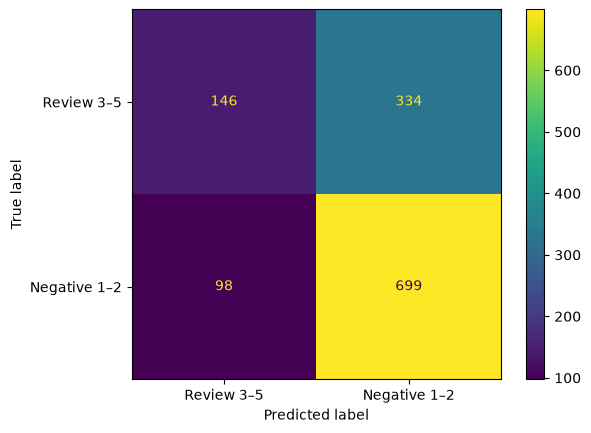

In [5]:
test_probability = model.predict_proba(X_test)[:, 1]
test_metrics = classification_metrics(y_test, test_probability, threshold=0.50)

display(pd.Series(test_metrics, name="test_set").round(3))

test_prediction = (test_probability >= 0.50).astype(int)
print(classification_report(
    y_test,
    test_prediction,
    target_names=["Review 3–5", "Negative review 1–2"],
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Review 3–5", "Negative 1–2"],
)


## 5. Interpret the model

Logistic Regression coefficients show which inputs are associated with higher or lower odds of a negative review while the other model variables are held fixed.

* Positive coefficient: associated with higher odds of a negative review.
* Negative coefficient: associated with lower odds.
* `exp(coefficient)` gives the odds ratio: above 1 means higher odds and below 1 means lower odds.

These are **associations, not causal effects**.


In [6]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})
coefficient_table["odds_ratio"] = np.exp(coefficient_table["coefficient"])

strongest_associations = pd.concat([
    coefficient_table.nsmallest(10, "coefficient"),
    coefficient_table.nlargest(10, "coefficient"),
]).drop_duplicates()

display(
    strongest_associations
    .sort_values("coefficient")
    .reset_index(drop=True)
    .round(3)
)


,feature,coefficient,odds_ratio
0,primary_product_category_christmas_supplies,-1.014,0.363
1,seller_state_ES,-0.978,0.376
2,primary_product_category_industry_commerce_and...,-0.896,0.408
3,primary_product_category_small_appliances,-0.764,0.466
4,seller_state_GO,-0.744,0.475
5,customer_state_TO,-0.718,0.488
6,primary_product_category_costruction_tools_garden,-0.673,0.510
7,primary_product_category_books_general_interest,-0.627,0.534
8,primary_product_category_food_drink,-0.617,0.540
9,seller_state_MT,-0.587,0.556


## 6. Save the model for Phase 3

`save_inference_artifact(...)` writes one `.pkl` containing the fitted preprocessing, fitted Logistic Regression, fixed 0.50 threshold, imported model feature contract, prediction point, and supporting metadata. This lets Phase 3 apply exactly the same fitted preprocessing during inference rather than recreating it.

The notebook then reloads the artifact and calls `predict_from_artifact(...)` for one held-out row. That helper validates the feature contract, produces the negative-review probability, and applies the saved threshold; it is a compact inference smoke check, not an additional evaluation or modelling step. Both helpers are implemented in `src/classification_model.py`.


In [7]:
ARTIFACT_PATH = PROJECT_ROOT / "deployment" / "late_order_negative_review_pipeline.pkl"

save_inference_artifact(
    model,
    str(ARTIFACT_PATH),
    threshold=0.50,
    metadata={
        "training_data_contract": "Phase 1 order_level.csv + item_level.csv",
        "model": "Logistic Regression",
        "classification_threshold": 0.50,
    },
)

import joblib

artifact = joblib.load(ARTIFACT_PATH)
display(predict_from_artifact(artifact, X_test.iloc[[0]]))
print(f"Saved model artifact: {ARTIFACT_PATH}")


,negative_review_probability,predicted_negative_review
3716,0.726467,1


Saved model artifact: c:\Users\Lenovo\Desktop\Team01_IT5006_Ecommerce_Analytics_AY2627Sem1\deployment\late_order_negative_review_pipeline.pkl
